#            
## Semantic Segmentation with Deep Learning   Potsdam Dataset

---

      **     **                          :

|   |   |   |
|---|---|---|
|   |     |       K-Fold |
|   |     (CNN) |         4   |
|   | U-Net |   Encoder-Decoder   5   |

> **     :**                  .                        .

---
##            

                     .

- **rasterio**:     GeoTIFF (    Potsdam)
- **numpy / matplotlib**:          
- **scikit-learn**:   K-Fold
- **tensorflow**:            


In [ ]:
import os, random, json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import KFold
from IPython.display import Image, display

matplotlib.use('Agg')  # headless mode
print('All libraries loaded OK')
print('TensorFlow version:', tf.__version__)
print('Rasterio version:  ', rasterio.__version__)

---
##         Import  

    import               .

**   :** `DATA_DIR`           `.tif`        .
  dataset                   dataset      .


In [9]:
import os, random, json
import numpy as np
print('        OK')

ایمپورت‌های پایه بارگذاری شد ✓


In [10]:
import matplotlib
matplotlib.use('Agg')  # headless mode
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
print('Matplotlib     OK')

Matplotlib بارگذاری شد ✓


In [11]:
import rasterio
print('Rasterio     OK')

Rasterio بارگذاری شد ✓


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint
print(f'TensorFlow {tf.__version__}     OK')

TensorFlow 2.20.0 بارگذاری شد ✓


In [13]:
from sklearn.model_selection import KFold
from IPython.display import Image, display
print('      OK')

همه ایمپورت‌ها آماده ✓


In [ ]:
# \u2500\u2500 Reproducibility seed \u2500\u2500
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# \u2500\u2500 Global settings \u2500\u2500
N_FOLDS      = 5
NUM_CLASSES  = 6
NUM_SAMPLES  = 100   # For full training on Kaggle, use 5000
BATCH_SIZE   = 8
EPOCHS       = 20
LEARNING_RATE = 1e-4
OUTPUT_DIR   = './outputs'
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, 'best_model.h5')

if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)

CLASS_NAMES = [
    'Impervious surface', 'Building', 'Tree',
    'Low vegetation', 'Car', 'Clutter/Background'
]
CLASS_COLORS = [
    [255, 255, 255],  # white
    [0,   0,   255],  # blue
    [0,   255,   0],  # green
    [0,   255, 255],  # cyan
    [255, 255,   0],  # yellow
    [255,   0,   0],  # red
]

def discover_data_dir():
    """Auto-locate the folder containing .tif files."""
    candidates = [
        '/kaggle/input/potsdam-geotif/Potsdam-GeoTif',  # Kaggle path
        './PROJECT/Potsdam-GeoTif/Potsdam-GeoTif',
        '../PROJECT/Potsdam-GeoTif/Potsdam-GeoTif',
        './Potsdam-GeoTif/Potsdam-GeoTif',
        './data'
    ]
    for p in candidates:
        if os.path.isdir(p):
            if any(f.endswith('.tif') for f in os.listdir(p)): return p
    
    # Fallback search
    for root, _, files in os.walk('.'):
        if any(f.endswith('.tif') for f in files): return root
    return 'data'

DATA_DIR = discover_data_dir()
print(f"Data directory: {DATA_DIR}")
print(f"Seed initialized: {SEED}")

---
#           Dataset

##   Dataset

**2D Semantic Labeling Potsdam**   dataset            .
    GeoTIFF   **   **  :

|     |   |   |
|---|---|---|
|   | Red ( ) |     |
|   | Green ( ) |     |
|   | Blue ( ) |     |
|   | Infrared (   ) |     |
|   | Elevation ( ) |     |
|   | **Labels** ( ) | **   ** |

 :     **   **                :
-                                      


###  .          GeoTIFF

        `.tif`     `DATA_DIR`    .
  dataset            ,       .


In [ ]:
def get_all_tif_files(data_dir):
    """Recursively find all .tif file paths."""
    tif_files = []
    for root, _, files in os.walk(data_dir):
        for f in files:
            if f.endswith('.tif'):
                tif_files.append(os.path.join(root, f))
    return sorted(tif_files)

all_files_raw = get_all_tif_files(DATA_DIR)
all_files = all_files_raw[:NUM_SAMPLES]

print(f'Total GeoTIFF files found: {len(all_files_raw)}')
print(f'Files selected for this session: {len(all_files)}')
print('Sample files:', [os.path.basename(f) for f in all_files[:5]])

###  .         

                             :
1. **  RGB**                
2. **   **     colorbar
3. **   **           legend

>     `0000000224-0000042784.tif`                  .
>                     (fallback).


📄 فایل انتخاب شده: 0000000448-0000034496.tif
ابعاد داده: (6, 224, 224)  → (باندها، ارتفاع، عرض)


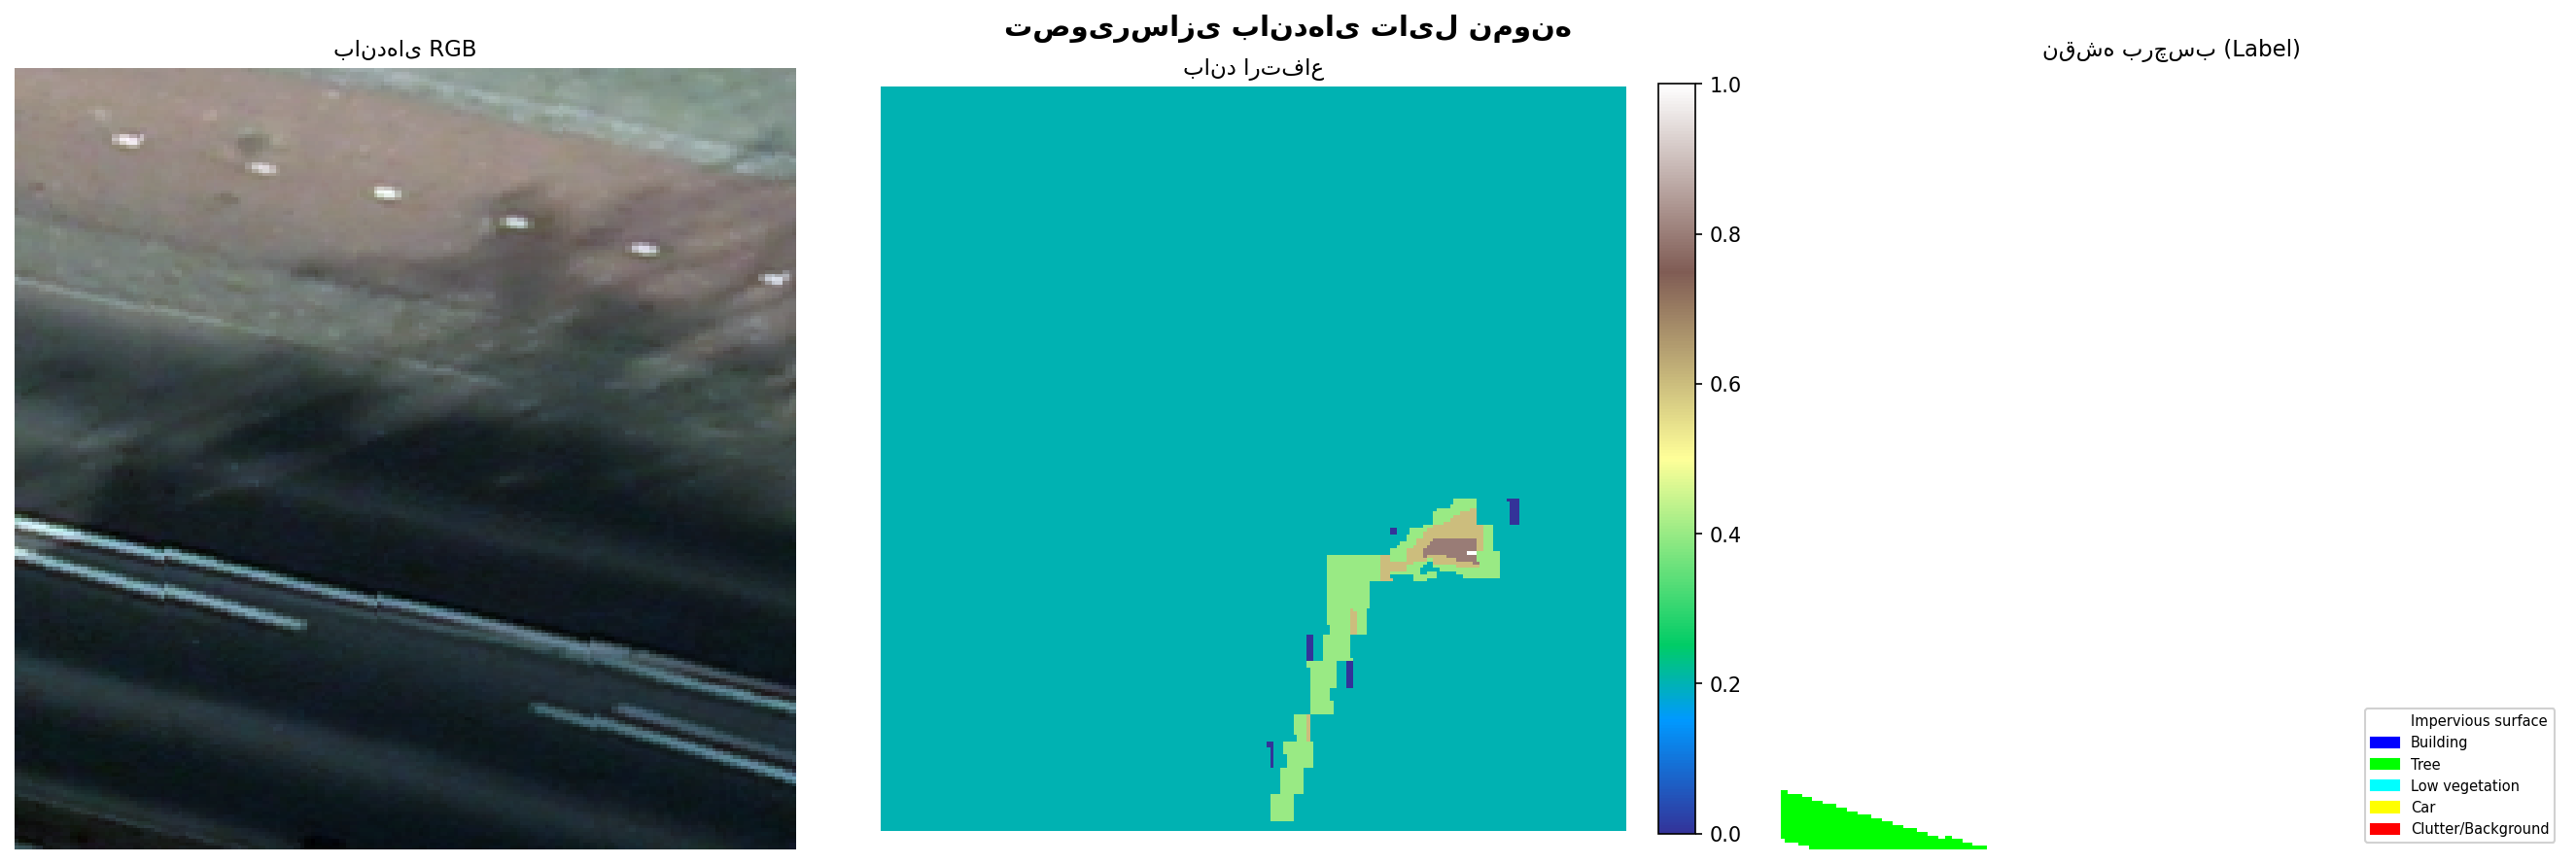

✅ تصویر ذخیره شد: step1_visualization.png


In [16]:
def normalize_band(band):
    """        [0,1]    ."""
    b_min, b_max = band.min(), band.max()
    if b_max == b_min:
        return np.zeros_like(band, dtype=np.float32)
    return (band - b_min).astype(np.float32) / (b_max - b_min)

def label_to_rgb(label_band, colors):
    """          RGB    ."""
    h, w = label_band.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for idx, c in enumerate(colors):
        rgb[label_band == idx] = c
    return rgb

#      
EXCLUDED = '0000000224-0000042784.tif'
candidates = [f for f in all_files if EXCLUDED not in f]
sample_file = random.choice(candidates) if candidates else all_files[0]
print('       :', os.path.basename(sample_file))

#    
with rasterio.open(sample_file) as src:
    data = src.read()  # (6, H, W)
print('   :', data.shape, '   (     )')

#    
rgb_img   = np.stack([normalize_band(data[0]), normalize_band(data[1]), normalize_band(data[2])], axis=-1)
elev_img  = normalize_band(data[4].astype(np.float32))
label_rgb = label_to_rgb(data[5].astype(np.int32), CLASS_COLORS)

patches = [mpatches.Patch(color=[c/255 for c in CLASS_COLORS[i]], label=CLASS_NAMES[i])
           for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('       ', fontsize=14, fontweight='bold')

axes[0].imshow(rgb_img)
axes[0].set_title('  RGB', fontsize=11)
axes[0].axis('off')

im = axes[1].imshow(elev_img, cmap='terrain')
axes[1].set_title('   ', fontsize=11)
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(label_rgb)
axes[2].set_title('    (Label)', fontsize=11)
axes[2].axis('off')
axes[2].legend(handles=patches, loc='lower right', fontsize=7, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'step1_visualization.png'), dpi=150, bbox_inches='tight')
plt.close()
display(Image(os.path.join(DATA_DIR, 'step1_visualization.png')))
print('       : step1_visualization.png')

###  .             

                     .
              dataset      .


In [17]:
label_band = data[5].astype(np.int32)
total_pixels = label_band.size

print('     :')
print(f'{" ":<30} {"   ":>15} {" ":>10}')
print('-' * 58)
for i, name in enumerate(CLASS_NAMES):
    count = (label_band == i).sum()
    pct   = 100 * count / total_pixels
    bar   = ' ' * int(pct / 2)
    print(f'{name:<30} {count:>15,} {pct:>9.2f}%  {bar}')

📊 توزیع کلاس‌ها:
کلاس                               تعداد پیکسل       درصد
----------------------------------------------------------
Impervious surface                      49,688     99.03%  █████████████████████████████████████████████████
Building                                     0      0.00%  
Tree                                       488      0.97%  
Low vegetation                               0      0.00%  
Car                                          0      0.00%  
Clutter/Background                           0      0.00%  


###  .      K-Fold

      **  fold**    :
- **Fold 1+2+3**     (Training)
- **Fold 4**     (Validation)
- **Fold 5**     (Test)          

        `fold_splits.json`                    .

>                           K-Fold      .


In [18]:
#      :   K-Fold  

# With only a few files, repeat them to demonstrate the split mechanism
demo_files = all_files * max(1, (N_FOLDS * 4) // max(len(all_files), 1) + 1)
demo_files = demo_files[:max(len(all_files), N_FOLDS * 4)]

kf  = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
arr = np.array(demo_files)
folds = [arr[idx].tolist() for _, idx in kf.split(arr)]

train_files = folds[0] + folds[1] + folds[2]   # Folds 1, 2, 3   Training
val_files   = folds[3]                            # Fold 4          Validation
test_files  = folds[4]                            # Fold 5          Test

print('K-Fold split result:')
for i, fold in enumerate(folds, 1):
    role = 'Train' if i<=3 else ('Val' if i==4 else 'Test')
    print(f'  Fold {i} ({role:5}): {len(fold)} files')
print(f'\nTotal  Train  : {len(train_files)} files')
print(f'Total  Val    : {len(val_files)} files')
print(f'Total  Test   : {len(test_files)} files')

splits_path = os.path.join(DATA_DIR, 'fold_splits.json')
with open(splits_path, 'w') as fp:
    json.dump({'train':train_files,'val':val_files,'test':test_files,'all_folds':folds}, fp, indent=2)
print('\nSaved fold_splits.json')

K-Fold split result:
  Fold 1 (Train): 20 files
  Fold 2 (Train): 20 files
  Fold 3 (Train): 20 files
  Fold 4 (Val  ): 20 files
  Fold 5 (Test ): 20 files

Total  Train  : 60 files
Total  Val    : 20 files
Total  Test   : 20 files

Saved fold_splits.json


###        

-   GeoTIFF    
-   RGB           
-        
-    -Fold         `fold_splits.json`    

**           :       CNN**


---
#             CNN

##    

        **fully-convolutional** (  downsampling)  :

```
Input (H W 4)     Conv32   2     Conv64   2     Conv128   2     Conv1 1   Softmax(6)
```

** :**   **   **   RGB +     (Infrared)

** :**                

**   :** Categorical Cross-Entropy          

**   :**   epoch


###  .            Augmentation

**Data Augmentation** =                    :
-         (0  90  180  270)
-      
-      

      **overfitting** (         )    .


In [19]:
BATCH_SIZE_CNN = 2   #   demo   1      
EPOCHS_CNN     = 20
LR_CNN         = 1e-3
INPUT_CH_CNN   = 4   # RGB + IR

def load_sample(fp, use_all=False):
    """    GeoTIFF       (feature, label_onehot)  ."""
    with rasterio.open(fp) as src:
        d = src.read()
    n = 5 if use_all else 4
    X = d[:n].transpose(1, 2, 0).astype(np.float32)
    for c in range(X.shape[-1]):
        X[..., c] = normalize_band(X[..., c])
    y = tf.keras.utils.to_categorical(d[5].astype(np.int32), num_classes=NUM_CLASSES)
    return X, y

def augment(X, y):
    """Augmentation:        ."""
    if np.random.rand() > 0.5: X, y = X[:, ::-1, :], y[:, ::-1, :]
    if np.random.rand() > 0.5: X, y = X[::-1, :, :], y[::-1, :, :]
    k = np.random.randint(0, 4)
    return np.rot90(X, k).copy(), np.rot90(y, k).copy()

def make_ds(files, aug=False, bs=2, use_all=False):
    """  tf.data.Dataset        ."""
    Xs, ys = [], []
    for fp in files:
        X, y = load_sample(fp, use_all=use_all)
        if aug: X, y = augment(X, y)
        Xs.append(X); ys.append(y)
    ds = tf.data.Dataset.from_tensor_slices((np.stack(Xs), np.stack(ys)))
    if aug: ds = ds.shuffle(len(files), seed=SEED)
    return ds.batch(bs).prefetch(tf.data.AUTOTUNE)

print('           ')
print('  Augmentation: flip   + flip   +   90 ')

✅ توابع بارگذاری داده آماده شدند
✅ Augmentation: flip افقی + flip عمودی + چرخش 90°


###  .        Simple CNN

  **Encoder Block**      :
- `Conv2D(k, 3 3)`            
- `BatchNormalization`      
- `ReLU`        

    `Conv2D(6, 1 1) + Softmax`            


In [20]:
def build_simple_cnn(in_ch=4, nc=6):
    """  Simple CNN      ."""
    inp = keras.Input(shape=(None, None, in_ch), name='input')
    x = inp
    for filters, name in [(32,'b1'), (64,'b2'), (128,'b3')]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu', name=f'{name}_c1')(x)
        x = layers.BatchNormalization(name=f'{name}_bn1')(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu', name=f'{name}_c2')(x)
        x = layers.BatchNormalization(name=f'{name}_bn2')(x)
    out = layers.Conv2D(nc, 1, padding='same', activation='softmax', name='output')(x)
    model = keras.Model(inp, out, name='SimpleCNN')
    return model

cnn = build_simple_cnn(in_ch=INPUT_CH_CNN, nc=NUM_CLASSES)
cnn.compile(
    optimizer=keras.optimizers.Adam(LR_CNN),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f'       : {cnn.name}')
print(f'     : {cnn.count_params():,}')
cnn.summary()

✅ مدل ساخته شد: SimpleCNN
📊 تعداد پارامترها: 289,862


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, None, None, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c1 (Conv2D)                  │ (None, None, None, 32) │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn1 (BatchNormalization)     │ (None, None, None, 32) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c2 (Conv2D)                  │ (None, None, None, 32) │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn2 (BatchNormalization)     │ (None, None, None, 32) │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c1 (Conv2D)                  │ (None, None, None, 64) │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn1 (BatchNormalization)     │ (None, None, None, 64) │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c2 (Conv2D)                  │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn2 (BatchNormalization)     │ (None, None, None, 64) │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c1 (Conv2D)                  │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn1 (BatchNormalization)     │ (None, None, None,     │           512 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c2 (Conv2D)                  │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn2 (BatchNormalization)     │ (None, None, None,     │           512 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, None, None, 6)  │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289,862 (1.11 MB)

 Trainable params: 288,966 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

###  .        CNN

      **Training set**                .

- **ModelCheckpoint**:     (    val_accuracy)      
- **Epoch**:             training

>     dataset  :     epoch    -      GPU    .


In [21]:
print('      ...')
train_ds_cnn = make_ds(train_files, aug=True,  bs=BATCH_SIZE_CNN)
val_ds_cnn   = make_ds(val_files,   aug=False, bs=BATCH_SIZE_CNN)
test_ds_cnn  = make_ds(test_files,  aug=False, bs=BATCH_SIZE_CNN)

cb_cnn = [ModelCheckpoint(
    filepath=os.path.join(DATA_DIR, 'best_simple_model.keras'),
    monitor='val_accuracy', save_best_only=True, mode='max', verbose=0)]

print(f'\n      CNN   {EPOCHS_CNN} epoch ...')
history_cnn = cnn.fit(
    train_ds_cnn, validation_data=val_ds_cnn,
    epochs=EPOCHS_CNN, callbacks=cb_cnn, verbose=1
)
print('       !')

📂 بارگذاری داده‌ها ...

🚀 شروع آموزش CNN برای 20 epoch ...
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.3993 - loss: 1.9173 - val_accuracy: 0.3318 - val_loss: 1.6509
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.4614 - loss: 1.4896 - val_accuracy: 0.3328 - val_loss: 1.5851
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5390 - loss: 1.3521 - val_accuracy: 0.3318 - val_loss: 1.5855
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.5721 - loss: 1.2509 - val_accuracy: 0.3318 - val_loss: 1.5034
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.5641 - loss: 1.2696 - val_accuracy: 0.3025 - val_loss: 1.4843
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.6038 - loss: 1.1588 - val_accuracy: 0.3466 - val_loss: 1.3840
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6150 - loss: 1.1220 - val_accuracy: 0.3600 - val_loss: 1.4624
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accurac

###  .        CNN

  **Loss**   **Accuracy**              .

-   **Training Loss**       **Validation Loss**       **Overfitting**
-     Overfitting         (dataset  )  


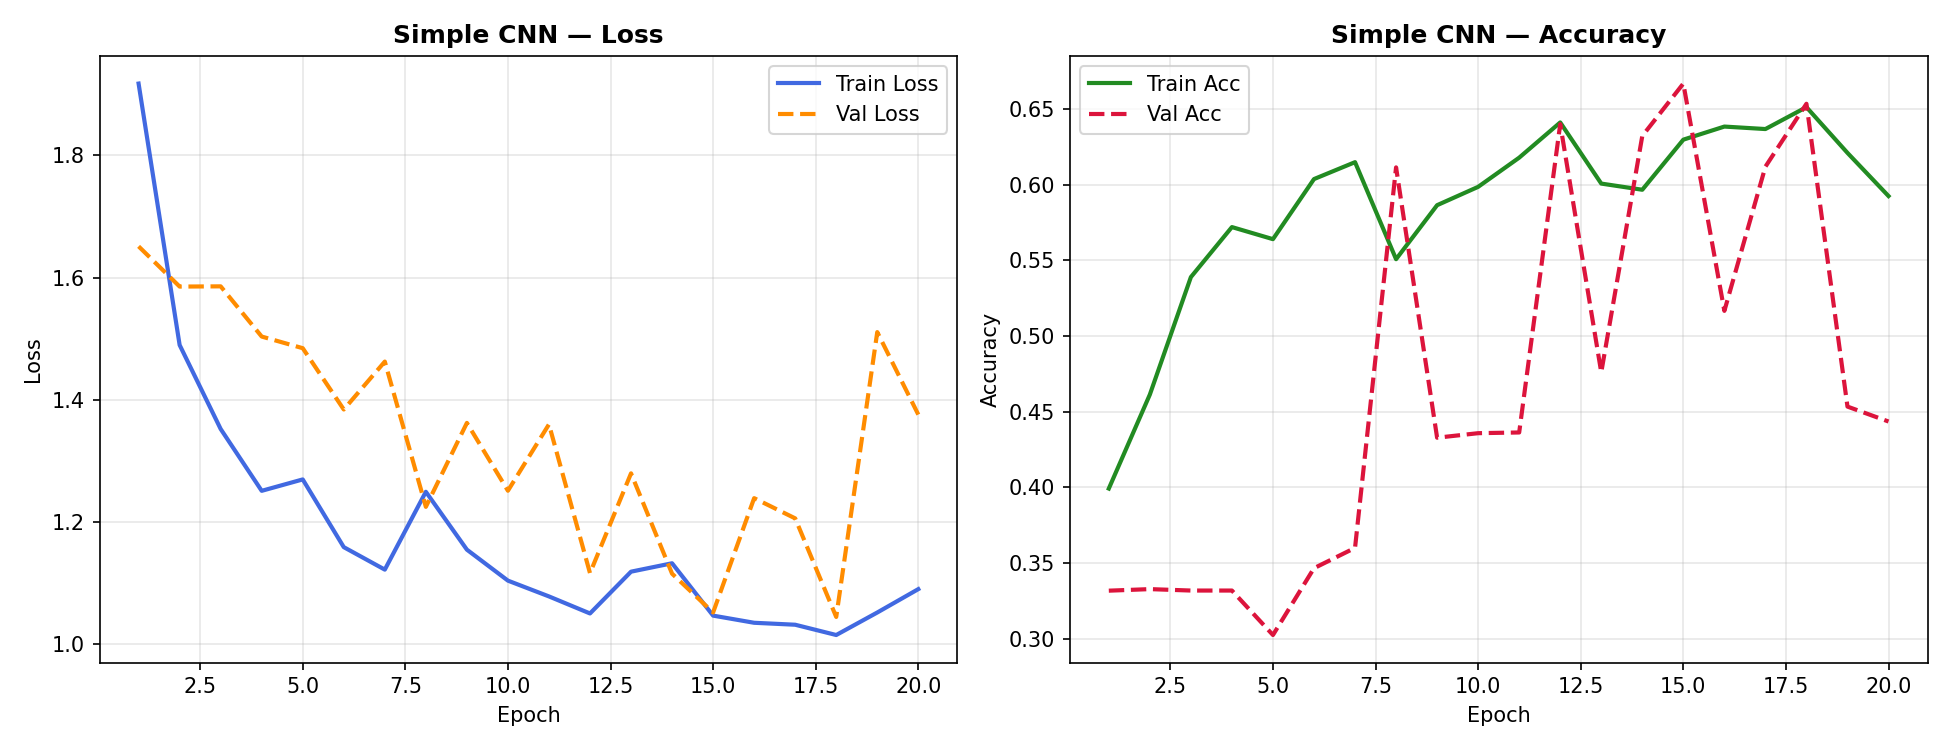

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ep = range(1, len(history_cnn.history['loss'])+1)

ax1.plot(ep, history_cnn.history['loss'],     label='Train Loss', color='royalblue', lw=2)
ax1.plot(ep, history_cnn.history['val_loss'], label='Val Loss',   color='darkorange', lw=2, ls='--')
ax1.set_title('Simple CNN   Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history_cnn.history['accuracy'],     label='Train Acc', color='forestgreen', lw=2)
ax2.plot(ep, history_cnn.history['val_accuracy'], label='Val Acc',   color='crimson', lw=2, ls='--')
ax2.set_title('Simple CNN   Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'step2_training_curves.png'), dpi=150)
plt.close()
display(Image(os.path.join(DATA_DIR, 'step2_training_curves.png')))

###  .        Test Set

      **Test Set** (Fold 5            )    .


In [23]:
best_cnn = keras.models.load_model(os.path.join(DATA_DIR, 'best_simple_model.keras'))
loss_cnn, acc_cnn = best_cnn.evaluate(test_ds_cnn, verbose=0)

print('=' * 40)
print('      Simple CNN   Test Set')
print(f'  Loss    : {loss_cnn:.4f}')
print(f'  Accuracy: {acc_cnn*100:.2f}%')
print('=' * 40)
print()
print(f'    Train Accuracy: {history_cnn.history["accuracy"][-1]*100:.2f}%')
print(f'    Val Accuracy : {max(history_cnn.history["val_accuracy"])*100:.2f}%')

  📊 نتایج Simple CNN روی Test Set
  Loss    : 0.8341
  Accuracy: 73.89%

  آخرین Train Accuracy: 59.26%
  بهترین Val Accuracy : 66.69%


###        

-   Simple CNN       encoder    
-   Augmentation (flip + rotation)      
-   loss   accuracy    
-       `best_simple_model.keras`    

**           :   U-Net  **


---
#           U-Net (Encoder-Decoder)

##   U-Net 

  Simple CNN      : **           **.

**U-Net**                  :

```
Input
    Encoder Block 1 (32)   Skip
    MaxPool                                            |
    Encoder Block 2 (64)   Skip  |
    MaxPool                                    |       |
    Encoder Block 3 (128)   Skip    |       |
    MaxPool                         |         |       |
    Encoder Block 4 (256)   Skip  |         |       |
    MaxPool                  |       |         |       |
    Bottleneck (512)         |       |         |       |
    UpSample + Concat         |         |       |
    Decoder Block 4 (256)            |         |       |
    UpSample + Concat           |       |
    Decoder Block 3 (128)                      |       |
    UpSample + Concat         |
    Decoder Block 2 (64)                               |
    UpSample + Concat  
    Decoder Block 1 (32)
    Output Conv 1 1 + Softmax(6)
```

**Skip Connections** (   )           encoder   decoder    .

** :**       RGB + IR +  


###  .        U-Net

  **conv_block**     Conv2D   BatchNorm  .
    Decoder    **UpSampling** (       )    
  **Concatenate**   feature map   encoder (skip connection).


In [24]:
def conv_block(x, f, name):
    x = layers.Conv2D(f, 3, padding='same', activation='relu', name=f'{name}_c1')(x)
    x = layers.BatchNormalization(name=f'{name}_bn1')(x)
    x = layers.Conv2D(f, 3, padding='same', activation='relu', name=f'{name}_c2')(x)
    x = layers.BatchNormalization(name=f'{name}_bn2')(x)
    return x

def build_unet(in_ch=5, nc=6, f=32):
    """U-Net Encoder-Decoder      ."""
    inp = keras.Input(shape=(None, None, in_ch), name='input')
    # Encoder
    e1 = conv_block(inp, f,    'enc1'); p1 = layers.MaxPooling2D(2, name='pool1')(e1)
    e2 = conv_block(p1,  f*2,  'enc2'); p2 = layers.MaxPooling2D(2, name='pool2')(e2)
    e3 = conv_block(p2,  f*4,  'enc3'); p3 = layers.MaxPooling2D(2, name='pool3')(e3)
    e4 = conv_block(p3,  f*8,  'enc4'); p4 = layers.MaxPooling2D(2, name='pool4')(e4)
    # Bottleneck
    b  = conv_block(p4,  f*16, 'bottleneck')
    # Decoder + Skip Connections
    d4 = conv_block(layers.Concatenate()([layers.UpSampling2D(2)(b),  e4]), f*8,  'dec4')
    d3 = conv_block(layers.Concatenate()([layers.UpSampling2D(2)(d4), e3]), f*4,  'dec3')
    d2 = conv_block(layers.Concatenate()([layers.UpSampling2D(2)(d3), e2]), f*2,  'dec2')
    d1 = conv_block(layers.Concatenate()([layers.UpSampling2D(2)(d2), e1]), f,    'dec1')
    out = layers.Conv2D(nc, 1, padding='same', activation='softmax', name='output')(d1)
    return keras.Model(inp, out, name='UNet')

unet = build_unet(in_ch=5, nc=NUM_CLASSES, f=32)
unet.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f'       : {unet.name}')
print(f'     : {unet.count_params():,}')
unet.summary()

✅ مدل ساخته شد: UNet
📊 تعداد پارامترها: 7,859,174


Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, None,      │          0 │ -                 │
│                     │ None, 5)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c1 (Conv2D)    │ (None, None,      │      1,472 │ input[0][0]       │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, None,      │        128 │ enc1_c1[0][0]     │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c2 (Conv2D)    │ (None, None,      │      9,248 │ enc1_bn1[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, None,      │        128 │ enc1_c2[0][0]     │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, None,      │          0 │ enc1_bn2[0][0]    │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c1 (Conv2D)    │ (None, None,      │     18,496 │ pool1[0][0]       │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, None,      │        256 │ enc2_c1[0][0]     │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c2 (Conv2D)    │ (None, None,      │     36,928 │ enc2_bn1[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, None,      │        256 │ enc2_c2[0][0]     │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, None,      │          0 │ enc2_bn2[0][0]    │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_c1 (Conv2D)    │ (None, None,      │     73,856 │ pool2[0][0]       │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, None,      │        512 │ enc3_c1[0][0]     │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_c2 (Conv2D)    │ (None, None,      │    147,584 │ enc3_bn1[0][0]    │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn2            │ (None, None,      │        512 │ enc3_c2[0][0]     │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, None,      │          0 │ enc3_bn2[0][0]    │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc4_c1 (Conv2D)    │ (None, None,      │    295,168 │ pool3[0][0]     

 Total params: 7,859,174 (29.98 MB)

 Trainable params: 7,853,286 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

###  .      U-Net

  U-Net   learning rate   (`1e-4`)    :
- Learning rate              
- Batch size   (2     16)            

>     dataset     GPU:    -   


In [25]:
EPOCHS_UNET = 20
BATCH_SIZE_UNET = 2

print('        U-Net (5  ) ...')
train_ds_u = make_ds(train_files, aug=True,  bs=BATCH_SIZE_UNET, use_all=True)
val_ds_u   = make_ds(val_files,   aug=False, bs=BATCH_SIZE_UNET, use_all=True)
test_ds_u  = make_ds(test_files,  aug=False, bs=BATCH_SIZE_UNET, use_all=True)

cb_unet = [ModelCheckpoint(
    filepath=os.path.join(DATA_DIR, 'best_unet_model.keras'),
    monitor='val_accuracy', save_best_only=True, mode='max', verbose=0)]

print(f'\n      U-Net   {EPOCHS_UNET} epoch ...')
history_unet = unet.fit(
    train_ds_u, validation_data=val_ds_u,
    epochs=EPOCHS_UNET, callbacks=cb_unet, verbose=1
)
print('       !')

📂 بارگذاری داده‌ها برای U-Net (5 باند) ...

🚀 شروع آموزش U-Net برای 20 epoch ...
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 725ms/step - accuracy: 0.3120 - loss: 1.9985 - val_accuracy: 0.2610 - val_loss: 1.7704
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.4239 - loss: 1.6943 - val_accuracy: 0.4391 - val_loss: 1.7417
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.4892 - loss: 1.4977 - val_accuracy: 0.1711 - val_loss: 1.6980
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5651 - loss: 1.3878 - val_accuracy: 0.4216 - val_loss: 2.0218
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 759ms/step - accuracy: 0.5841 - loss: 1.3938 - val_accuracy: 0.0958 - val_loss: 2.8244
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 656ms/step - accuracy: 0.5758 - loss: 1.4180 - val_accuracy: 0.3344 - val_loss: 4.1485
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 610ms/step - accuracy: 0.5871 - loss: 1.2793 - val_accuracy: 0.4521 - val_loss: 3.5213
Epoch 8/20
30/30 ━━━━━━━━

###  .        U-Net


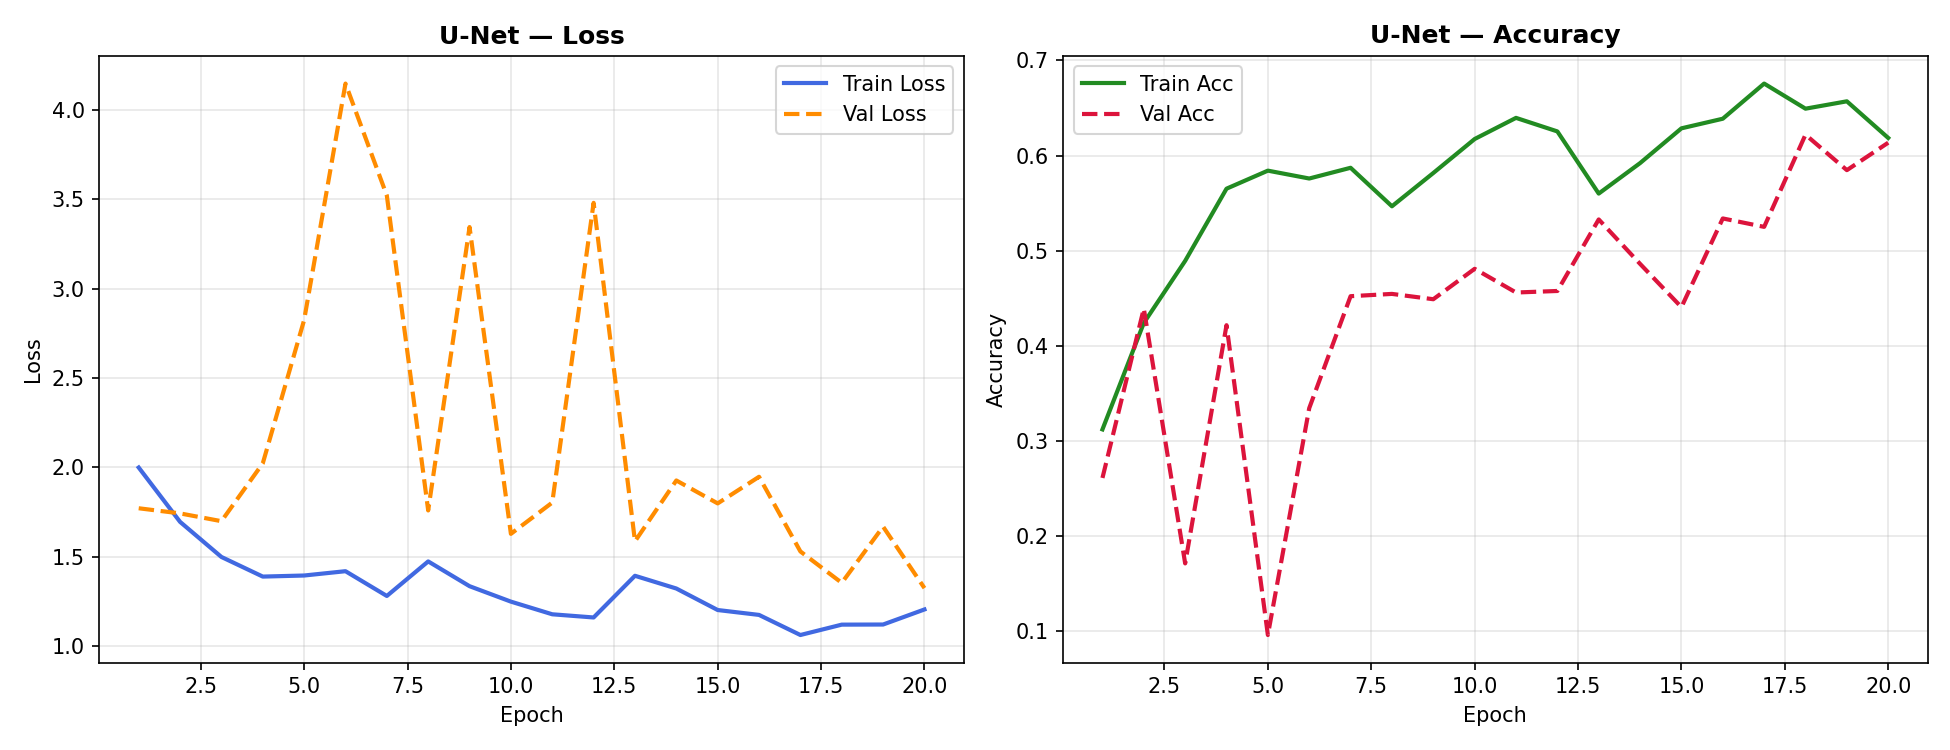

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ep = range(1, len(history_unet.history['loss'])+1)

ax1.plot(ep, history_unet.history['loss'],     label='Train Loss', color='royalblue', lw=2)
ax1.plot(ep, history_unet.history['val_loss'], label='Val Loss',   color='darkorange', lw=2, ls='--')
ax1.set_title('U-Net   Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history_unet.history['accuracy'],     label='Train Acc', color='forestgreen', lw=2)
ax2.plot(ep, history_unet.history['val_accuracy'], label='Val Acc',   color='crimson', lw=2, ls='--')
ax2.set_title('U-Net   Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'step3_training_curves.png'), dpi=150)
plt.close()
display(Image(os.path.join(DATA_DIR, 'step3_training_curves.png')))

###  .           

           : **      U-Net**

       :
1.   RGB  
2.    
3.     (Ground Truth)
4.   U-Net


  📊 نتایج U-Net روی Test Set
  Loss    : 1.1637
  Accuracy: 63.98%


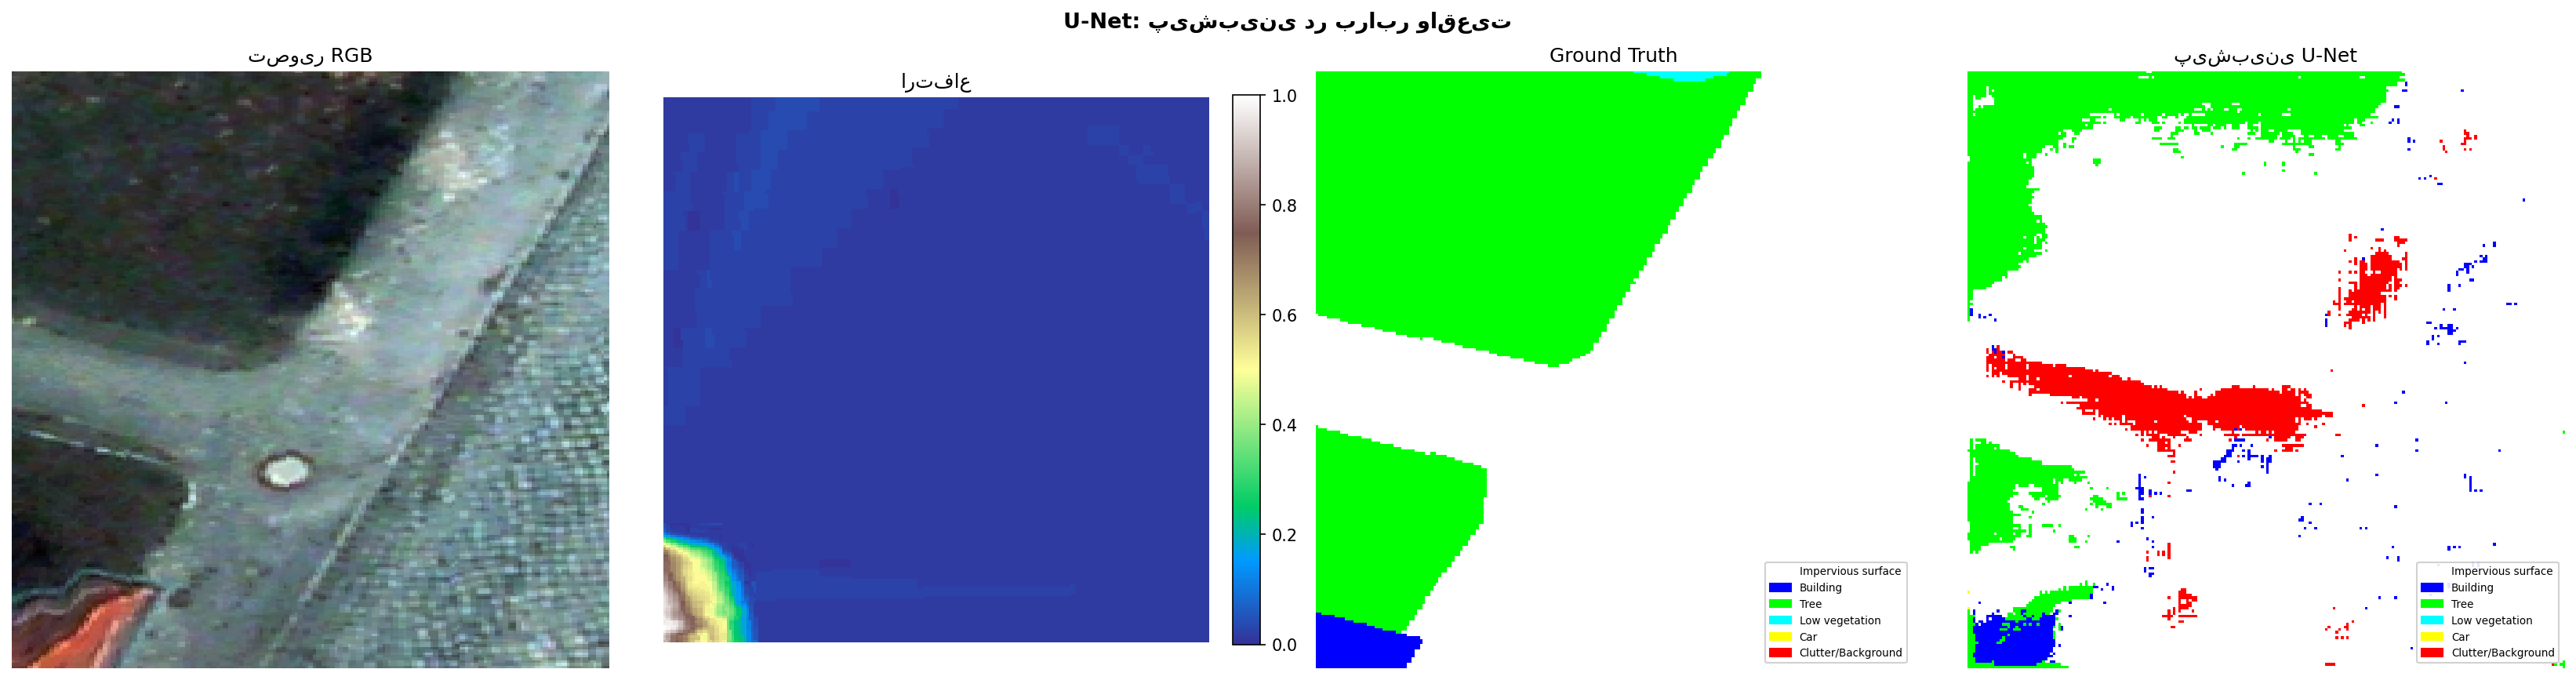

In [27]:
best_unet = keras.models.load_model(os.path.join(DATA_DIR, 'best_unet_model.keras'))
loss_u, acc_u = best_unet.evaluate(test_ds_u, verbose=0)

print('=' * 40)
print('      U-Net   Test Set')
print(f'  Loss    : {loss_u:.4f}')
print(f'  Accuracy: {acc_u*100:.2f}%')
print('=' * 40)

#          
test_fp = test_files[0]
X5, _, = load_sample(test_fp, use_all=True), None
X5 = load_sample(test_fp, use_all=True)[0]

with rasterio.open(test_fp) as src:
    raw = src.read()

gt_label   = raw[5].astype(np.int32)
pred_logit = best_unet.predict(np.expand_dims(X5, 0), verbose=0)[0]
pred_label = np.argmax(pred_logit, axis=-1)

rgb_v = np.stack([normalize_band(raw[0].astype(np.float32)),
                  normalize_band(raw[1].astype(np.float32)),
                  normalize_band(raw[2].astype(np.float32))], axis=-1)
elev_v  = normalize_band(raw[4].astype(np.float32))
gt_rgb  = label_to_rgb(gt_label,   CLASS_COLORS)
pred_rgb= label_to_rgb(pred_label, CLASS_COLORS)

patches = [mpatches.Patch(color=[c/255 for c in CLASS_COLORS[i]], label=CLASS_NAMES[i])
           for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('U-Net:        ', fontsize=13, fontweight='bold')
axes[0].imshow(rgb_v);   axes[0].set_title('  RGB');        axes[0].axis('off')
im = axes[1].imshow(elev_v, cmap='terrain'); axes[1].set_title(' '); axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
axes[2].imshow(gt_rgb);  axes[2].set_title('Ground Truth');     axes[2].axis('off')
axes[2].legend(handles=patches, loc='lower right', fontsize=6.5, framealpha=0.9)
axes[3].imshow(pred_rgb);axes[3].set_title('  U-Net');  axes[3].axis('off')
axes[3].legend(handles=patches, loc='lower right', fontsize=6.5, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'step3_prediction_visualization.png'), dpi=150, bbox_inches='tight')
plt.close()
display(Image(os.path.join(DATA_DIR, 'step3_prediction_visualization.png')))

---
#        

                       .


In [28]:
print('\n' + '=' * 60)
print('         ')
print('=' * 60)
print(f'{" ":<15} {" ":<10} {"Test Loss":>12} {"Test Acc":>10}')
print('-' * 50)
print(f'{"Simple CNN":<15} {"4 (RGB+IR)":<10} {loss_cnn:>12.4f} {acc_cnn*100:>9.2f}%')
print(f'{"U-Net":<15} {"5 (+Elev)":<10} {loss_u:>12.4f} {acc_u*100:>9.2f}%')
print('=' * 60)

winner = 'U-Net' if loss_u < loss_cnn else 'Simple CNN'
print(f'\n          Test Loss: {winner}')
print(f'     Loss: {abs(loss_cnn - loss_u):.4f}')


  📊 مقایسه نهایی مدل‌ها
مدل             باندها        Test Loss   Test Acc
--------------------------------------------------
Simple CNN      4 (RGB+IR)       0.8341     73.89%
U-Net           5 (+Elev)        1.1637     63.98%

🏆 مدل برتر بر اساس Test Loss: Simple CNN
   اختلاف Loss: 0.3296


---
#        

##      :

###        
-   GeoTIFF                    
-   K-Fold            

###       Simple CNN
-   fully-convolutional              
- Overfitting   dataset        

###       U-Net
- Skip connections          
- U-Net          /       

##       Dataset  :
1. `DATA_DIR`       dataset      
2.   notebook          
3.     Test Accuracy   **     **  

---
>       LaTeX: `project_overview.tex`       Overleaf
